Firstly, The assignement isrelated on How mental health is dependent on social media. Mental health has many different factors such as trauma, ptsd, sucidal thoughts and more. For the analysis we have consider Three conditions which are related to mental health they are anxiety, addiction, ADHD (Attention-deficit/hyperactivity disorder).

I have three datasets on each factor. 

Now in coming step we are going to clean the datasets. 

In [ ]:
#libraries
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

!pip install imbalanced-learn
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from nltk.sentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vivekkumar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vivekkumar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#loading the datasets.

#dataset 1 

anxiety_data = pd.read_csv("/Users/vivekkumar/Desktop/nlpcp2/anxiety_pre_features_tfidf_256.csv")
#print(anxiety_data.head(10))

#dataset 2
adhd_data = pd.read_csv("/Users/vivekkumar/Desktop/nlpcp2/adhd_pre_features_tfidf_256.csv")
#print(adhd_data.head(10))

print("datasets imported")


datasets imported


Data preparation:

We want to two different datasets into one dataset in the next step.

In [3]:
# Step 3: Combine
mentalhealth_data = pd.concat([adhd_data, anxiety_data], ignore_index=True)

print("Full data shape:", mentalhealth_data.shape)
print("\nLabel (subreddit) distribution:")
print(mentalhealth_data["subreddit"].value_counts())

Full data shape: (36672, 350)

Label (subreddit) distribution:
subreddit
anxiety    19976
adhd       16696
Name: count, dtype: int64


In [4]:
print(mentalhealth_data.head(10))

  subreddit            author        date  \
0      adhd           S-Kay21  2019/01/18   
1      adhd          lismox42  2019/01/18   
2      adhd  reddit_noob_1234  2019/01/18   
3      adhd        JITTERdUdE  2019/01/18   
4      adhd  buddingaddiction  2019/01/18   
5      adhd        lilstevo29  2019/01/18   
6      adhd            sojayn  2019/01/18   
7      adhd       inciterinia  2019/01/18   
8      adhd       WalkTheDork  2019/01/18   
9      adhd        mononiongo  2019/01/18   

                                                post  \
0  How much further ahead could I have been by no...   
1  ADHD &amp; Bipolar Anyone else have Bipolar Di...   
2  My relationship is falling apart and I don’t k...   
3  To those struggling to write papers- drink cof...   
4  Meds didn't cure chronic laziness But I can fo...   
5  Why does this always happen to me? School is i...   
6  With an understanding that my brain still need...   
7  How do I explain to people that I have a very ...   


Next line of code is to see how the different factors in the dataset weight in the mental health data.

In [5]:
mentalhealth_data["subreddit"].value_counts(normalize=True) * 100


subreddit
anxiety    54.472077
adhd       45.527923
Name: proportion, dtype: float64

The results says most of your samples come from the anxiety dataset with 53.736482 percent. Next comes adhd data with 44.913111 data. 

In the next step, The dataset have lot of unwanted columns. so we dropped the columns.

In [6]:
columns_drop = [
    'automated_readability_index','coleman_liau_index','flesch_kincaid_grade_level',
    'flesch_reading_ease','gulpease_index','gunning_fog_index','lix','smog_index',
    'wiener_sachtextformel','n_chars','n_long_words','n_monosyllable_words',
    'n_polysyllable_words','n_sents','n_syllables','n_unique_words','n_words',
    'sent_neg','sent_neu','sent_pos','sent_compound','economic_stress_total',
    'isolation_total','substance_use_total','guns_total','domestic_stress_total',
    'suicidality_total','punctuation','liwc_1st_pers','liwc_2nd_pers','liwc_3rd_pers',
    'liwc_achievement','liwc_adverbs','liwc_affective_processes','liwc_anger',
    'liwc_anxiety','liwc_articles_article','liwc_assent','liwc_auxiliary_verbs',
    'liwc_biological','liwc_body','liwc_causation','liwc_certainty','liwc_cognitive',
    'liwc_common_verbs','liwc_conjunctions','liwc_death','liwc_discrepancy',
    'liwc_exclusive','liwc_family','liwc_feel','liwc_fillers','liwc_friends',
    'liwc_future_tense','liwc_health','liwc_hear','liwc_home','liwc_humans',
    'liwc_impersonal_pronouns','liwc_inclusive','liwc_ingestion','liwc_inhibition',
    'liwc_insight','liwc_leisure','liwc_money','liwc_motion','liwc_negations',
    'liwc_negative_emotion','liwc_nonfluencies','liwc_numbers','liwc_past_tense',
    'liwc_perceptual_processes','liwc_personal_pronouns','liwc_positive_emotion',
    'liwc_prepositions','liwc_present_tense','liwc_quantifiers','liwc_relativity',
    'liwc_religion','liwc_sadness','liwc_see','liwc_sexual','liwc_social_processes',
    'liwc_space','liwc_swear_words','liwc_tentative','liwc_time',
    'liwc_total_functional','liwc_total_pronouns','liwc_work',
    # now all tfidf columns
    'tfidf_abl','tfidf_abus','tfidf_actual','tfidf_addict','tfidf_adhd','tfidf_advic',
    'tfidf_ago','tfidf_alcohol','tfidf_almost','tfidf_alon','tfidf_alreadi',
    'tfidf_also','tfidf_alway','tfidf_amp','tfidf_amp x200b','tfidf_ani',
    'tfidf_anoth','tfidf_anxieti','tfidf_anxious','tfidf_anymor','tfidf_anyon',
    'tfidf_anyon els','tfidf_anyth','tfidf_around','tfidf_ask','tfidf_attack',
    'tfidf_away','tfidf_back','tfidf_bad','tfidf_becaus','tfidf_becom','tfidf_befor',
    'tfidf_believ','tfidf_best','tfidf_better','tfidf_bit','tfidf_bodi','tfidf_bpd',
    'tfidf_brain','tfidf_call','tfidf_came','tfidf_care','tfidf_caus','tfidf_chang',
    'tfidf_come','tfidf_complet','tfidf_constant','tfidf_control','tfidf_could',
    'tfidf_coupl','tfidf_cri','tfidf_day','tfidf_deal','tfidf_depress','tfidf_diagnos',
    'tfidf_die','tfidf_differ','tfidf_disord','tfidf_doctor','tfidf_doe','tfidf_done',
    'tfidf_dont','tfidf_drink','tfidf_drug','tfidf_eat','tfidf_els','tfidf_emot',
    'tfidf_end','tfidf_enough','tfidf_etc','tfidf_even','tfidf_ever','tfidf_everi',
    'tfidf_everyon','tfidf_everyth','tfidf_experi','tfidf_famili','tfidf_fear',
    'tfidf_feel','tfidf_feel like','tfidf_felt','tfidf_final','tfidf_find',
    'tfidf_first','tfidf_food','tfidf_found','tfidf_friend','tfidf_fuck','tfidf_get',
    'tfidf_give','tfidf_go','tfidf_good','tfidf_got','tfidf_great','tfidf_guess',
    'tfidf_guy','tfidf_happen','tfidf_happi','tfidf_hard','tfidf_hate','tfidf_head',
    'tfidf_health','tfidf_hear','tfidf_heart','tfidf_help','tfidf_high','tfidf_home',
    'tfidf_hope','tfidf_hour','tfidf_hous','tfidf_hurt','tfidf_idea','tfidf_im',
    'tfidf_issu','tfidf_job','tfidf_keep','tfidf_kill','tfidf_kind','tfidf_know',
    'tfidf_last','tfidf_late','tfidf_leav','tfidf_left','tfidf_let','tfidf_life',
    'tfidf_like','tfidf_littl','tfidf_live','tfidf_long','tfidf_look','tfidf_lose',
    'tfidf_lost','tfidf_lot','tfidf_love','tfidf_made','tfidf_make','tfidf_mani',
    'tfidf_mayb','tfidf_mean','tfidf_med','tfidf_medic','tfidf_mental','tfidf_might',
    'tfidf_mind','tfidf_mom','tfidf_month','tfidf_move','tfidf_much','tfidf_need',
    'tfidf_never','tfidf_new','tfidf_next','tfidf_night','tfidf_normal','tfidf_noth',
    'tfidf_notic','tfidf_old','tfidf_onc','tfidf_one','tfidf_onli','tfidf_pain',
    'tfidf_panic','tfidf_parent','tfidf_part','tfidf_past','tfidf_peopl',
    'tfidf_person','tfidf_place','tfidf_pleas','tfidf_point','tfidf_possibl',
    'tfidf_post','tfidf_pretti','tfidf_probabl','tfidf_problem','tfidf_ptsd',
    'tfidf_put','tfidf_question','tfidf_quit','tfidf_read','tfidf_real','tfidf_realli',
    'tfidf_reason','tfidf_recent','tfidf_relationship','tfidf_rememb','tfidf_right',
    'tfidf_said','tfidf_say','tfidf_scare','tfidf_school','tfidf_see','tfidf_seem',
    'tfidf_self','tfidf_sever','tfidf_shit','tfidf_sinc','tfidf_situat','tfidf_sleep',
    'tfidf_social','tfidf_someon','tfidf_someth','tfidf_sometim','tfidf_sorri',
    'tfidf_start','tfidf_stay','tfidf_still','tfidf_stop','tfidf_stress',
    'tfidf_struggl','tfidf_stuff','tfidf_suicid','tfidf_support','tfidf_sure',
    'tfidf_symptom','tfidf_take','tfidf_talk','tfidf_tell','tfidf_thank','tfidf_therapi',
    'tfidf_therapist','tfidf_thing','tfidf_think','tfidf_though','tfidf_thought',
    'tfidf_time','tfidf_tire','tfidf_today','tfidf_told','tfidf_took','tfidf_tri',
    'tfidf_turn','tfidf_two','tfidf_understand','tfidf_us','tfidf_use','tfidf_usual',
    'tfidf_veri','tfidf_want','tfidf_way','tfidf_week','tfidf_weight','tfidf_well',
    'tfidf_went','tfidf_whi','tfidf_whole','tfidf_wish','tfidf_without','tfidf_wonder',
    'tfidf_work','tfidf_worri','tfidf_wors','tfidf_would','tfidf_wrong','tfidf_x200b',
    'tfidf_year'
]

#drop columns which are un wanted 

final_mentalhealth_data = mentalhealth_data.drop(columns=columns_drop,
                                                 errors='ignore')

print("\nAfter dropping:")
print("Shape:", final_mentalhealth_data.shape)
print("Remaining columns:", len(final_mentalhealth_data.columns))
print(final_mentalhealth_data.head(5))

#output path
output_path = "/Users/vivekkumar/Desktop/finaldataset2.csv"
final_mentalhealth_data.to_csv(output_path, index=False)



After dropping:
Shape: (36672, 4)
Remaining columns: 4
  subreddit            author        date  \
0      adhd           S-Kay21  2019/01/18   
1      adhd          lismox42  2019/01/18   
2      adhd  reddit_noob_1234  2019/01/18   
3      adhd        JITTERdUdE  2019/01/18   
4      adhd  buddingaddiction  2019/01/18   

                                                post  
0  How much further ahead could I have been by no...  
1  ADHD &amp; Bipolar Anyone else have Bipolar Di...  
2  My relationship is falling apart and I don’t k...  
3  To those struggling to write papers- drink cof...  
4  Meds didn't cure chronic laziness But I can fo...  


importing dataset 

In [7]:
final_dataset = pd.read_csv("/Users/vivekkumar/Desktop/finaldataset2.csv")

print(final_dataset.head(10))

  subreddit            author        date  \
0      adhd           S-Kay21  2019/01/18   
1      adhd          lismox42  2019/01/18   
2      adhd  reddit_noob_1234  2019/01/18   
3      adhd        JITTERdUdE  2019/01/18   
4      adhd  buddingaddiction  2019/01/18   
5      adhd        lilstevo29  2019/01/18   
6      adhd            sojayn  2019/01/18   
7      adhd       inciterinia  2019/01/18   
8      adhd       WalkTheDork  2019/01/18   
9      adhd        mononiongo  2019/01/18   

                                                post  
0  How much further ahead could I have been by no...  
1  ADHD &amp; Bipolar Anyone else have Bipolar Di...  
2  My relationship is falling apart and I don’t k...  
3  To those struggling to write papers- drink cof...  
4  Meds didn't cure chronic laziness But I can fo...  
5  Why does this always happen to me? School is i...  
6  With an understanding that my brain still need...  
7  How do I explain to people that I have a very ...  
8  I thou

In [8]:
#renamming column
final_dataset = final_dataset.rename(columns={'subreddit': 'factors'})



In the next step we are planning to do remove the stopwords for every post. 

In [9]:
print("shape of dataset:", final_dataset.shape)
print("Columns:", final_dataset.columns.tolist())

#in this step we want remove stop words.
stop_words = set(stopwords.words('english'))

#creating function to remove stopwords
def removing_stopwords(text):
    if not isinstance(text, str):
        return ""
    #converting text to lowercase and tokenize
    words = word_tokenize(text.lower())
    filtered_words = [w for w in words if w.isalpha() and w not in stop_words]
    #join cleaned words back into a string
    return " ".join(filtered_words)

#creating new column
#using function created to remove stopwords
final_dataset['post_no_stopwords'] = final_dataset['post'].apply(removing_stopwords)  #apply the function

print("\n Sample preview:")
print(final_dataset[['post', 'post_no_stopwords']].head())

output_path = "/Users/vivekkumar/Desktop/stopwords_dataset.csv"
mentalhealth_data.to_csv(output_path, index=False)
print(f"\n Combined dataset saved as: {output_path}")


shape of dataset: (36672, 4)
Columns: ['factors', 'author', 'date', 'post']

 Sample preview:
                                                post  \
0  How much further ahead could I have been by no...   
1  ADHD &amp; Bipolar Anyone else have Bipolar Di...   
2  My relationship is falling apart and I don’t k...   
3  To those struggling to write papers- drink cof...   
4  Meds didn't cure chronic laziness But I can fo...   

                                   post_no_stopwords  
0  much ahead could vent sorry long one diagnosed...  
1  adhd amp bipolar anyone else bipolar disorder ...  
2  relationship falling apart know bf feeling rea...  
3  struggling write drink coffee start week early...  
4  meds cure chronic laziness focus intently some...  

 Combined dataset saved as: /Users/vivekkumar/Desktop/stopwords_dataset.csv


baseline solution

Dataset
Shape: (36672, 5)
Columns: ['factors', 'author', 'date', 'post', 'post_no_stopwords']
  factors            author        date  \
0    adhd           S-Kay21  2019/01/18   
1    adhd          lismox42  2019/01/18   
2    adhd  reddit_noob_1234  2019/01/18   

                                                post  \
0  How much further ahead could I have been by no...   
1  ADHD &amp; Bipolar Anyone else have Bipolar Di...   
2  My relationship is falling apart and I don’t k...   

                                   post_no_stopwords  
0  much ahead could vent sorry long one diagnosed...  
1  adhd amp bipolar anyone else bipolar disorder ...  
2  relationship falling apart know bf feeling rea...  

Train size: 29337
Test size: 7335

TF-IDF train shape: (29337, 5000)

Results: 
Accuracy: 0.9451

Classification Report:

              precision    recall  f1-score   support

        adhd       0.94      0.94      0.94      3339
     anxiety       0.95      0.95      0.95      3996

 

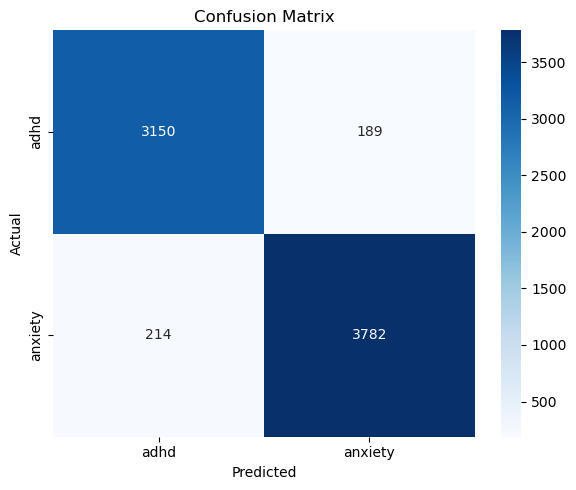

In [10]:
print("Dataset")
print("Shape:", final_dataset.shape)
print("Columns:", final_dataset.columns.tolist())
print(final_dataset.head(3))

text_col = "post_no_stopwords"   # cleaned text
label_col = "factors"            # mental health factor labels

#training and testing data
X = final_dataset[text_col]
y = final_dataset[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

#Tf Idf vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"  # extra safety
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF train shape:", X_train_tfidf.shape)


#logistic regression
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

#fitting the model
baseline_model.fit(X_train_tfidf, y_train)

#prediction
y_pred = baseline_model.predict(X_test_tfidf)

print("\nResults: ")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=baseline_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=baseline_model.classes_, yticklabels=baseline_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



In [11]:
feature_names = tfidf.get_feature_names_out()
coefs = baseline_model.coef_
classes = baseline_model.classes_

print("Classes:", classes)
print("coef_ shape:", coefs.shape)

n_coef_rows = coefs.shape[0]
n_classes = len(classes)

if n_coef_rows == 1:

    coef_vec = coefs[0]

    if n_classes == 2:
        pos_class = classes[1]
        neg_class = classes[0]

        top_pos_idx = coef_vec.argsort()[-10:]
        top_pos_words = [feature_names[j] for j in top_pos_idx]
        print(f"\nTop words for class '{pos_class}' (positive direction):")
        print(top_pos_words)

        top_neg_idx = coef_vec.argsort()[:10]
        top_neg_words = [feature_names[j] for j in top_neg_idx]
        print(f"\nTop words for class '{neg_class}' (negative direction):")
        print(top_neg_words)
    else:
        print("\n[Warning] Model has 1 coef row but", n_classes,
              "classes. Skipping top-words per class because shapes don't match.")

else:
    for i, class_label in enumerate(classes):
        coef_vec = coefs[i]
        top10_idx = coef_vec.argsort()[-10:]
        top10_words = [feature_names[j] for j in top10_idx]
        print(f"\nTop words for class '{class_label}':")
        print(top10_words)


Classes: ['adhd' 'anxiety']
coef_ shape: (1, 5000)

Top words for class 'anxiety' (positive direction):
['worrying', 'gad', 'afraid', 'attack', 'zoloft', 'fear', 'scared', 'panic', 'anxious', 'anxiety']

Top words for class 'adhd' (negative direction):
['adhd', 'adderall', 'vyvanse', 'add', 'concerta', 'ritalin', 'diagnosed', 'meds', 'focus', 'rsd']


checking shape of  the dataset 


Original class distribution:
factors
anxiety    19976
adhd       16696
Name: count, dtype: int64


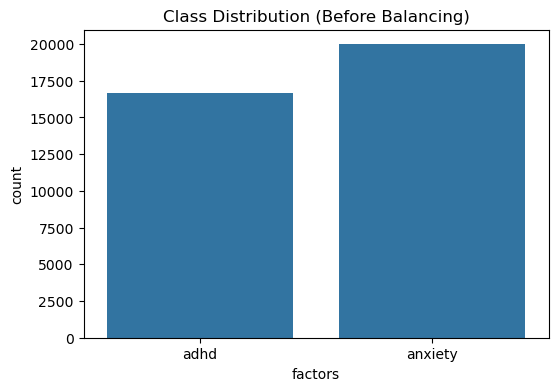

In [12]:
print("\nOriginal class distribution:")
print(final_dataset['factors'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='factors', data=final_dataset)
plt.title("Class Distribution (Before Balancing)")
plt.xticks(rotation=0)
plt.show()


slicing down the rows to balance the data 

In [13]:
#count
print(final_dataset['factors'].value_counts())

smallest_count = final_dataset['factors'].value_counts().min()

#undersampling anxiety, and keep ADHD same size
df_balanced = (
    final_dataset.groupby('factors', group_keys=False)
                 .apply(lambda x: x.sample(smallest_count, random_state=42))
)

print("\nAfter undersampling:")
print(df_balanced['factors'].value_counts())

#path
output_path = "/Users/vivekkumar/Desktop/balanceddata.csv"  
df_balanced.to_csv(output_path, index=False)
print("\nSaved to:", output_path)


factors
anxiety    19976
adhd       16696
Name: count, dtype: int64

After undersampling:
factors
adhd       16696
anxiety    16696
Name: count, dtype: int64


/var/folders/8q/k_54hxvx05x5ml7_73sk06wm0000gn/T/ipykernel_91811/928146384.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(smallest_count, random_state=42))



Saved to: /Users/vivekkumar/Desktop/balanceddata.csv


Importing balanced dataset 

In [14]:
balanced_dataset = pd.read_csv("/Users/vivekkumar/Desktop/balanceddata.csv")

print(balanced_dataset.head(10))

  factors                author        date  \
0    adhd         bestpics99899  2018/11/03   
1    adhd             Redd_Hawk  2019/02/26   
2    adhd  ignoretheimplication  2019/09/24   
3    adhd             rayjensen  2019/02/26   
4    adhd        theappleisalie  2019/05/19   
5    adhd          GinPlaceJoke  2019/07/08   
6    adhd               TVLord5  2019/10/06   
7    adhd          buddahbatman  2019/06/08   
8    adhd            Biggins_CV  2019/05/02   
9    adhd     ChrissyChrissyPie  2019/04/24   

                                                post  \
0  I hate math It takes an insane amount of conce...   
1  Infos on ADHD with ODD Hi,\n\nSo I started a r...   
2  What’s your go-to strategy for lighting a fire...   
3  Do adhd meds help with the social anxiety caus...   
4  Question for those medicated and working on an...   
5  What do I do now? I lost my script due to mult...   
6  Any strategies for RSD in a crowd? I get dragg...   
7  Unpleasant medication review Af

research question 1

How effectively can NLP models detect mental-health conditions such as anxiety, addiction, and ADHD using text-based linguistic features extracted from social-media posts?

In [15]:

print("Columns in dataset:", balanced_dataset.columns.tolist())
print("\nSample rows:")
print(balanced_dataset[['post_no_stopwords', 'factors']].head())


#train and test data split 
input_text = balanced_dataset["post_no_stopwords"].astype(str)
output_labels = balanced_dataset["factors"].astype(str)

#split into 80 : 20.  
input_train, input_test, output_train, output_test = train_test_split(
    input_text, output_labels,
    test_size=0.2,
    random_state=42,
    stratify=output_labels
)

#size
print("\nTrain size:", input_train.shape[0])
print("Test size:", input_test.shape[0])

#tf idf feature extraction
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

#fitting model 
input_train_tfidf = tfidf.fit_transform(input_train)
input_test_tfidf  = tfidf.transform(input_test)

print("\nTF-IDF feature matrix shape (train):", input_train_tfidf.shape)
print("TF-IDF feature matrix shape (test):", input_test_tfidf.shape)

#training model
lr = LogisticRegression(max_iter=1000, n_jobs=-1)
nb = MultinomialNB()
svm = LinearSVC()

#fitting model 
lr.fit(input_train_tfidf, output_train)
nb.fit(input_train_tfidf, output_train)
svm.fit(input_train_tfidf, output_train)

#all three models
models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "SVM": svm
}

results = []

for name, model in models.items():
    print("\n" + "="*60)
    print(f"Evaluating model: {name}")

    #fit the model here
    model.fit(input_train_tfidf, output_train)

    #predict
    y_pred = model.predict(input_test_tfidf)

    #accuracy
    acc = accuracy_score(output_test, y_pred)
    print(f"{name} Accuracy: {acc:.3f}\n")

    #classification report
    print("Classification Report:")
    print(classification_report(output_test, y_pred))

    results.append((name, acc))

print("\n" + "="*60)
print("Models that actually ran:")
for name, acc in results:
    print(f"{name}: {acc:.3f}")






Columns in dataset: ['factors', 'author', 'date', 'post', 'post_no_stopwords']

Sample rows:
                                   post_no_stopwords factors
0  hate math takes insane amount concentration si...    adhd
1  infos adhd odd hi started relationship girl ad...    adhd
2  strategy lighting fire butt productive instead...    adhd
3  adhd meds help social anxiety caused adhd went...    adhd
4  question medicated working advanced degree phd...    adhd

Train size: 26713
Test size: 6679

TF-IDF feature matrix shape (train): (26713, 5000)
TF-IDF feature matrix shape (test): (6679, 5000)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



Evaluating model: Logistic Regression
Logistic Regression Accuracy: 0.939

Classification Report:
              precision    recall  f1-score   support

        adhd       0.94      0.94      0.94      3340
     anxiety       0.94      0.94      0.94      3339

    accuracy                           0.94      6679
   macro avg       0.94      0.94      0.94      6679
weighted avg       0.94      0.94      0.94      6679


Evaluating model: Naive Bayes
Naive Bayes Accuracy: 0.912

Classification Report:
              precision    recall  f1-score   support

        adhd       0.92      0.90      0.91      3340
     anxiety       0.91      0.92      0.91      3339

    accuracy                           0.91      6679
   macro avg       0.91      0.91      0.91      6679
weighted avg       0.91      0.91      0.91      6679


Evaluating model: SVM
SVM Accuracy: 0.931

Classification Report:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

        adhd       0.93      0.93      0.93      3340
     anxiety       0.93      0.93      0.93      3339

    accuracy                           0.93      6679
   macro avg       0.93      0.93      0.93      6679
weighted avg       0.93      0.93      0.93      6679


Models that actually ran:
Logistic Regression: 0.939
Naive Bayes: 0.912
SVM: 0.931


<Figure size 600x500 with 0 Axes>

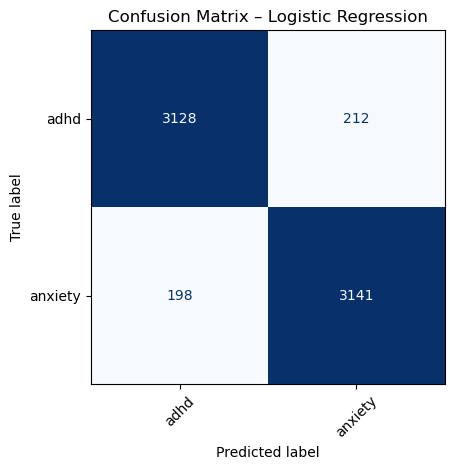

<Figure size 600x500 with 0 Axes>

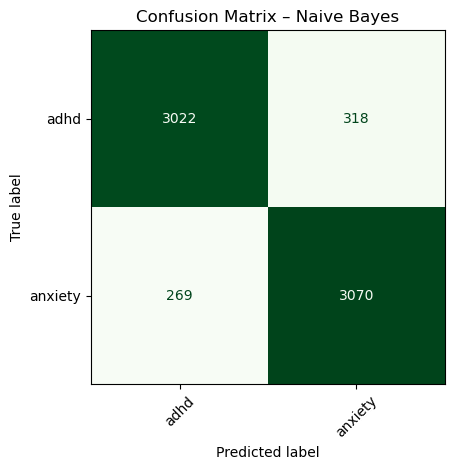

<Figure size 600x500 with 0 Axes>

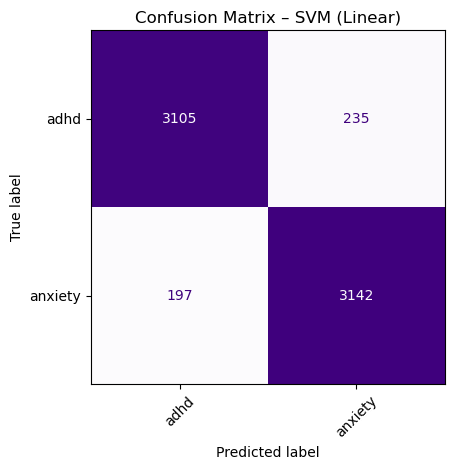

In [16]:
#svm
svm = SVC(kernel='linear', C=1.0, random_state=42)
svm.fit(input_train_tfidf, output_train)

#predicting using all models 
y_pred_lr  = lr.predict(input_test_tfidf)
y_pred_nb  = nb.predict(input_test_tfidf)
y_pred_svm = svm.predict(input_test_tfidf)

#confusion matrix for logistic regression 
cm_lr = confusion_matrix(output_test, y_pred_lr, labels=lr.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr.classes_)
plt.figure(figsize=(6,5))
disp_lr.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix – Logistic Regression")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#confusion matrix for naive bayes
cm_nb = confusion_matrix(output_test, y_pred_nb, labels=nb.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb.classes_)
plt.figure(figsize=(6,5))
disp_nb.plot(cmap="Greens", colorbar=False)
plt.title("Confusion Matrix – Naive Bayes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#confusion matrix for svm
cm_svm = confusion_matrix(output_test, y_pred_svm, labels=svm.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm.classes_)
plt.figure(figsize=(6,5))
disp_svm.plot(cmap="Purples", colorbar=False)
plt.title("Confusion Matrix – SVM (Linear)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


research question 2

What specific language patterns and emotional expressions (e.g., happiness, sadness, stress-related sentiment) are associated with different mental health conditions in social media text?

In [17]:
!pip install nrclex


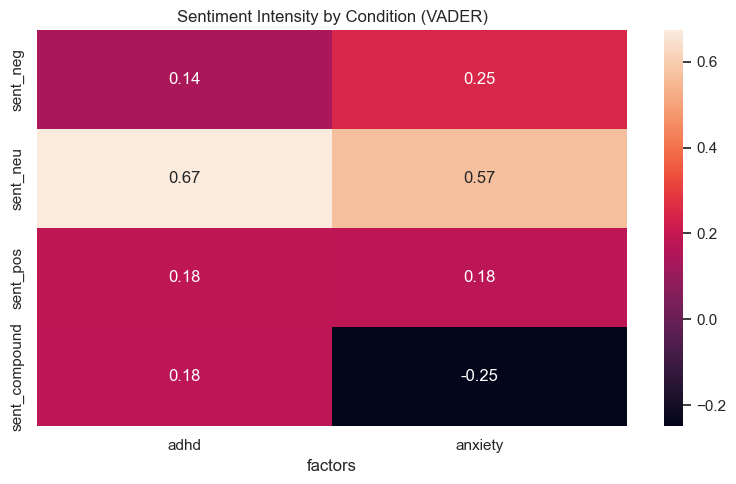

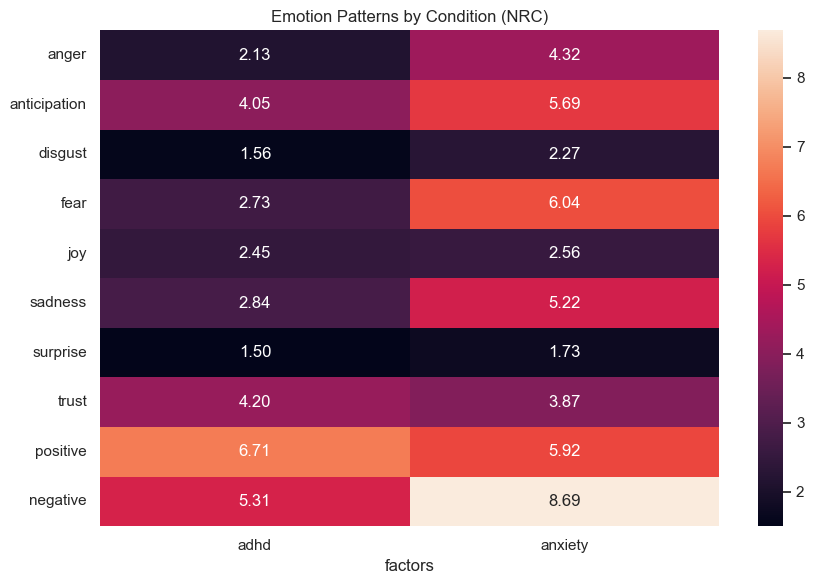

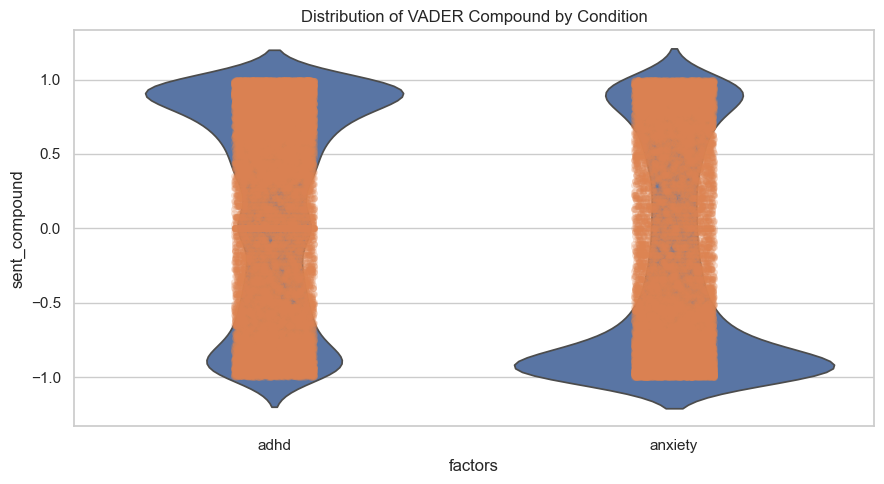

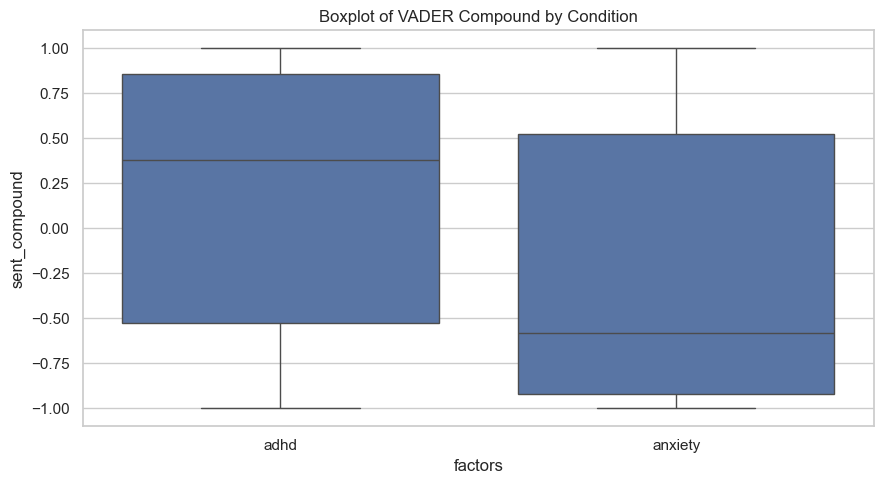

In [18]:
sns.set(style="whitegrid")

#sentimental analysis
sia = SentimentIntensityAnalyzer()

#data paths
balanced_dataset['sent_neg']      = balanced_dataset['post_no_stopwords'].apply(lambda x: sia.polarity_scores(x)['neg'])
balanced_dataset['sent_neu']      = balanced_dataset['post_no_stopwords'].apply(lambda x: sia.polarity_scores(x)['neu'])
balanced_dataset['sent_pos']      = balanced_dataset['post_no_stopwords'].apply(lambda x: sia.polarity_scores(x)['pos'])
balanced_dataset['sent_compound'] = balanced_dataset['post_no_stopwords'].apply(lambda x: sia.polarity_scores(x)['compound'])

#nrc emotions
def get_nrc_emotions(text):
    emo = NRCLex(text)
    e = emo.raw_emotion_scores
    return {
        'anger':        e.get('anger', 0),
        'anticipation': e.get('anticipation', 0),
        'disgust':      e.get('disgust', 0),
        'fear':         e.get('fear', 0),
        'joy':          e.get('joy', 0),
        'sadness':      e.get('sadness', 0),
        'surprise':     e.get('surprise', 0),
        'trust':        e.get('trust', 0),
        'positive':     e.get('positive', 0),
        'negative':     e.get('negative', 0)
    }

nrc_df = balanced_dataset['post_no_stopwords'].apply(lambda x: pd.Series(get_nrc_emotions(x)))
balanced_dataset = pd.concat([balanced_dataset, nrc_df], axis=1)

label_col = "factors"

#sentiment heatmap  
sentiment_cols = ['sent_neg','sent_neu','sent_pos','sent_compound']
sent_profile = balanced_dataset.groupby(label_col)[sentiment_cols].mean().round(3)

#plot for sentiment intensity
plt.figure(figsize=(8,5))
sns.heatmap(sent_profile.T, annot=True, fmt=".2f")
plt.title("Sentiment Intensity by Condition (VADER)")
plt.tight_layout()
plt.show()

nrc_cols = ["anger","anticipation","disgust","fear","joy","sadness","surprise","trust","positive","negative"]

#plot for emotion patterns
nrc_profile = balanced_dataset.groupby(label_col)[nrc_cols].mean().round(3)
plt.figure(figsize=(9,6))
sns.heatmap(nrc_profile.T, annot=True, fmt=".2f")
plt.title("Emotion Patterns by Condition (NRC)")
plt.tight_layout()
plt.show()

#plots distribution of VADER compound
plt.figure(figsize=(9,5))
sns.violinplot(data=balanced_dataset, x=label_col, y='sent_compound', inner=None)
sns.stripplot(data=balanced_dataset, x=label_col, y='sent_compound', alpha=0.25)
plt.title("Distribution of VADER Compound by Condition")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sns.boxplot(data=balanced_dataset, x=label_col, y='sent_compound')
plt.title("Boxplot of VADER Compound by Condition")
plt.tight_layout()
plt.show()



Research question 3

How well do topic modeling and sentiment analysis reveal underlying psychological themes such as loneliness, panic, and recovery in social media text?


balanced_dataset columns: ['factors', 'author', 'date', 'post', 'post_no_stopwords', 'sent_neg', 'sent_neu', 'sent_pos', 'sent_compound', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust', 'positive', 'negative']
Using TEXT='post_no_stopwords', CLASS='factors' → renamed to TEXT/CLASS.
Final df shape for RQ3: (33392, 2)
NRC emotions computed.
X_counts shape: (33392, 15000)

=== Sentiment by Topic ===
       sent_neg  sent_neu  sent_pos  sent_compound
topic                                             
0         0.313     0.547     0.140         -0.483
1         0.273     0.549     0.178         -0.356
2         0.162     0.664     0.174          0.061
3         0.216     0.593     0.192         -0.110
4         0.133     0.698     0.169          0.158
5         0.166     0.632     0.202          0.156


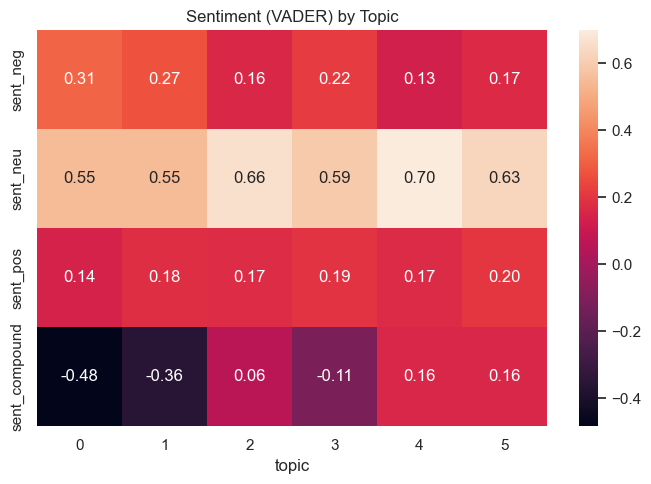

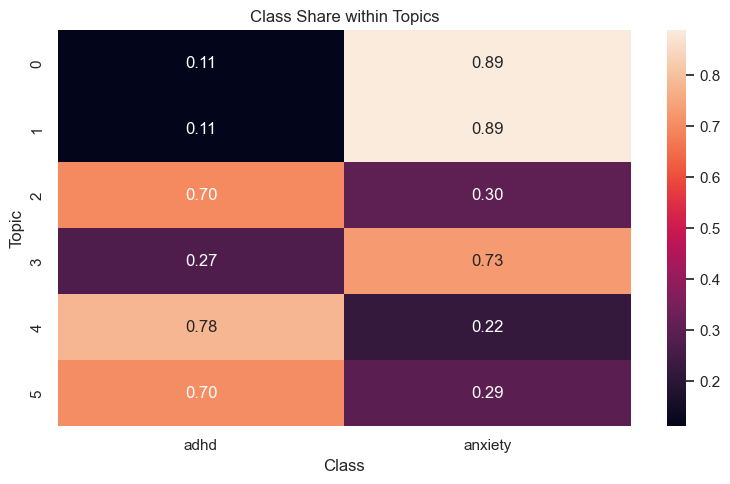

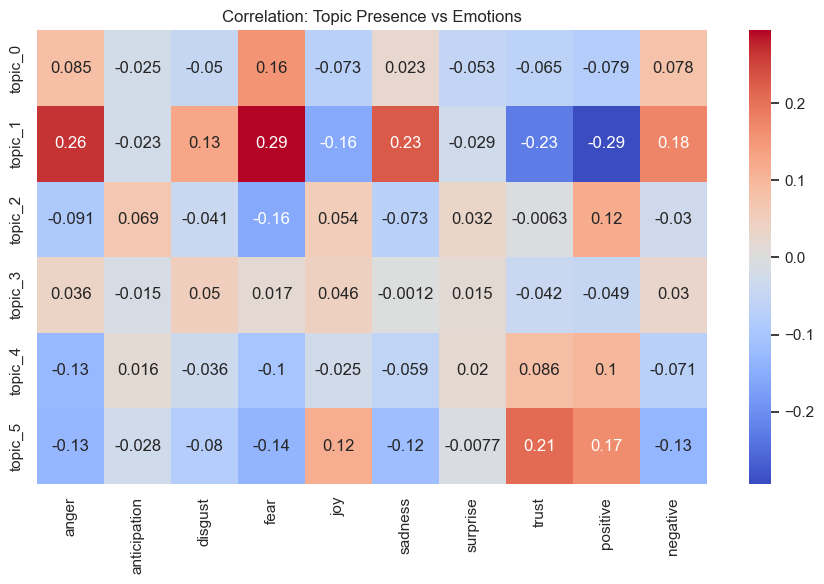


Saved outputs to: rq3_outputs
{
  "num_topics": 6,
  "topic_labels": {
    "0": "anxiety, panic, attack, attacks, panic attack, panic attacks",
    "1": "anxiety, feel, like, feel like, feeling, really",
    "2": "work, time, job, like, day, things",
    "3": "know, got, like, going, really, friends",
    "4": "medication, meds, taking, doctor, adderall, day",
    "5": "adhd, like, life, people, know, school"
  },
  "files": {
    "topic_top_words_csv": [
      "topic_0_top_words.csv",
      "topic_1_top_words.csv",
      "topic_2_top_words.csv",
      "topic_3_top_words.csv",
      "topic_4_top_words.csv",
      "topic_5_top_words.csv"
    ],
    "topic_sentiment_profile": "topic_sentiment_profile.csv",
    "topic_class_counts": "topic_class_counts.csv",
    "topic_class_share": "topic_class_share.csv",
    "topic_nrc_profile": "topic_nrc_profile.csv",
    "figures": [
      "topic_class_share_heatmap.png",
      "topic_sentiment_heatmap.png",
      "topic_emotion_correlation_heatmap

In [19]:
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

#setting the topics
NUM_TOPICS   = 6
MAX_FEATURES = 15000 
MIN_DF       = 5
MAX_DF       = 0.90
NGRAM_RANGE  = (1,2)

SAVE_DIR = "rq3_outputs"
FIG_DIR  = os.path.join(SAVE_DIR, "figs")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

#checking data
cols = list(balanced_dataset.columns)
print("balanced_dataset columns:", cols)

if ("TEXT" in cols) and ("CLASS" in cols):
    df = balanced_dataset[["TEXT", "CLASS"]].dropna().copy()
    print("Using existing TEXT/CLASS columns.")
else:
    text_col_candidates = []
    if "post_no_stopwords" in cols:
        text_col_candidates.append("post_no_stopwords")
    if "post" in cols:
        text_col_candidates.append("post")

    if not text_col_candidates:
        raise ValueError(
            "Could not find a text column. Expected 'TEXT' or 'post_no_stopwords' or 'post'. "
            f"Available columns: {cols}"
        )

    text_col = "post_no_stopwords" if "post_no_stopwords" in cols else text_col_candidates[0]

    if "factors" not in cols:
        raise ValueError(
            "Could not find label column 'factors' or 'CLASS'. "
            f"Available columns: {cols}"
        )

    label_col = "factors"
    df = balanced_dataset[[text_col, label_col]].dropna().rename(
        columns={text_col: "TEXT", label_col: "CLASS"}
    )
    print(f"Using TEXT='{text_col}', CLASS='{label_col}' → renamed to TEXT/CLASS.")

df.reset_index(drop=True, inplace=True)
print("Final df shape for RQ3:", df.shape)


#SENTIMENT (VADER)
sia = SentimentIntensityAnalyzer()

def vader_scores(text):
    s = sia.polarity_scores(str(text))
    return s["neg"], s["neu"], s["pos"], s["compound"]

df[["sent_neg","sent_neu","sent_pos","sent_compound"]] = df["TEXT"].apply(
    lambda x: pd.Series(vader_scores(x))
)

NRC_CATS = [
    "anger","anticipation","disgust","fear","joy",
    "sadness","surprise","trust","positive","negative"
]

have_nrc = False
try:
    from nrclex import NRCLex

    def nrc_scores(x):
        emo = NRCLex(str(x))
        raw = emo.raw_emotion_scores
        tot = sum(raw.values()) or 1
        return [raw.get(c,0)/tot for c in NRC_CATS]

    df[NRC_CATS] = df["TEXT"].apply(lambda x: pd.Series(nrc_scores(x)))
    have_nrc = True
    print("NRC emotions computed.")
except Exception as e:
    print("NRC not available — skipping NRC features.", e)

#LDA 
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES
)

X_counts = vectorizer.fit_transform(df["TEXT"])
vocab = np.array(vectorizer.get_feature_names_out())
print("X_counts shape:", X_counts.shape)

lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    max_iter=10,              
    learning_method="online",  
    random_state=42,
    n_jobs=1,
    batch_size=512
)

doc_topic = lda.fit_transform(X_counts)
topic_word = lda.components_

df["topic"] = doc_topic.argmax(axis=1)


def top_words_for_topic(tid, k=20):
    row = topic_word[tid]
    top_idx = row.argsort()[-k:][::-1]
    return pd.DataFrame({
        "rank": range(1, k+1),
        "token": vocab[top_idx],
        "weight": row[top_idx].round(4)
    })

topic_summaries = {}
for t in range(NUM_TOPICS):
    tw = top_words_for_topic(t)
    tw.to_csv(os.path.join(SAVE_DIR, f"topic_{t}_top_words.csv"), index=False)
    topic_summaries[t] = tw

#sentiment by topic
sent_cols = ["sent_neg","sent_neu","sent_pos","sent_compound"]
topic_sent = df.groupby("topic")[sent_cols].mean().round(3)
topic_sent.to_csv(os.path.join(SAVE_DIR, "topic_sentiment_profile.csv"))

print("\n=== Sentiment by Topic ===")
print(topic_sent)

#class with topics
topic_class_ct  = pd.crosstab(df["topic"], df["CLASS"])
topic_class_pct = (topic_class_ct.T / topic_class_ct.T.sum()).T.round(3)

topic_class_ct.to_csv(os.path.join(SAVE_DIR, "topic_class_counts.csv"))
topic_class_pct.to_csv(os.path.join(SAVE_DIR, "topic_class_share.csv"))



#topic with emotion 
topic_dummy = pd.get_dummies(df["topic"], prefix="topic")

if have_nrc:
    emotion_data = df[NRC_CATS]
else:
    emotion_data = df[["sent_neg","sent_neu","sent_pos","sent_compound"]]

corr_matrix = pd.concat([topic_dummy, emotion_data], axis=1).corr()
corr_pivot  = corr_matrix.loc[topic_dummy.columns, emotion_data.columns]

sns.set(style="whitegrid")

#sentiment by topic
plt.figure(figsize=(7,5))
sns.heatmap(topic_sent.T, annot=True, fmt=".2f")
plt.title("Sentiment (VADER) by Topic")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "topic_sentiment_heatmap.png"), dpi=250)
plt.show()

#class share within topics
plt.figure(figsize=(8,5))
sns.heatmap(topic_class_pct, annot=True, fmt=".2f")
plt.title("Class Share within Topics")
plt.xlabel("Class"); plt.ylabel("Topic")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "topic_class_share_heatmap.png"), dpi=250)
plt.show()

#topic vs emotion correlation
plt.figure(figsize=(9,6))
sns.heatmap(corr_pivot, annot=True, center=0, cmap="coolwarm")
plt.title("Correlation: Topic Presence vs Emotions")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "topic_emotion_correlation_heatmap.png"), dpi=250)
plt.show()


topic_labels = {
    t: ", ".join(topic_summaries[t]["token"].head(6).tolist())
    for t in range(NUM_TOPICS)
}

summary = {
    "num_topics": NUM_TOPICS,
    "topic_labels": topic_labels,
    "files": {
        "topic_top_words_csv": [f"topic_{t}_top_words.csv" for t in range(NUM_TOPICS)],
        "topic_sentiment_profile": "topic_sentiment_profile.csv",
        "topic_class_counts": "topic_class_counts.csv",
        "topic_class_share": "topic_class_share.csv",
        "topic_nrc_profile": ("topic_nrc_profile.csv" if have_nrc else None),
        "figures": os.listdir(FIG_DIR)
    }
}

with open(os.path.join(SAVE_DIR, "rq3_topic_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved outputs to:", SAVE_DIR)
print(json.dumps(summary, indent=2))


code reference:

1. https://www.nltk.org/
2. https://www.geeksforgeeks.org/python/python-sentiment-analysis-using-vader/
3. https://www.geeksforgeeks.org/nlp/topic-modeling-using-latent-dirichlet-allocation-lda/
